# Analisis Alura Store Latam
### Challenge Data Science — Recomendacion de venta de tienda para el Sr. Juan

## Importacion de datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Carga de datos desde archivos CSV locales
tienda  = pd.read_csv('tienda_1_.csv')
tienda2 = pd.read_csv('tienda_2.csv')
tienda3 = pd.read_csv('tienda_3.csv')
tienda4 = pd.read_csv('tienda_4.csv')

tiendas = {
    'Tienda 1': tienda,
    'Tienda 2': tienda2,
    'Tienda 3': tienda3,
    'Tienda 4': tienda4
}
NOMBRES = list(tiendas.keys())
COLORES = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

print("Datos cargados correctamente")
for nombre, df in tiendas.items():
    print(f"  {nombre}: {len(df)} registros")
tienda.head()

Datos cargados correctamente
  Tienda 1: 2359 registros
  Tienda 2: 2359 registros
  Tienda 3: 2359 registros
  Tienda 4: 2358 registros


## 1. Analisis de Facturacion (Ingresos Totales)
Sumamos los valores de la columna `Precio` de cada tienda para estimar los ingresos totales.

In [1]:
ingresos = {nombre: df['Precio'].sum() for nombre, df in tiendas.items()}

print("Ingresos totales por tienda:")
print("-" * 45)
for nombre, ingreso in ingresos.items():
    print(f"  {nombre}: ${ingreso:,.0f} COP")

ingreso_max = max(ingresos, key=ingresos.get)
ingreso_min = min(ingresos, key=ingresos.get)
print(f"\nMayor ingreso: {ingreso_max} (${ingresos[ingreso_max]:,.0f})")
print(f"Menor ingreso: {ingreso_min} (${ingresos[ingreso_min]:,.0f})")

Ingresos totales por tienda:
---------------------------------------------
  Tienda 1: $1,150,880,400 COP
  Tienda 2: $1,116,343,500 COP
  Tienda 3: $1,098,019,600 COP
  Tienda 4: $1,038,375,700 COP

Mayor ingreso: Tienda 1 ($1,150,880,400)
Menor ingreso: Tienda 4 ($1,038,375,700)


### Grafico 1 — Ingresos Totales por Tienda

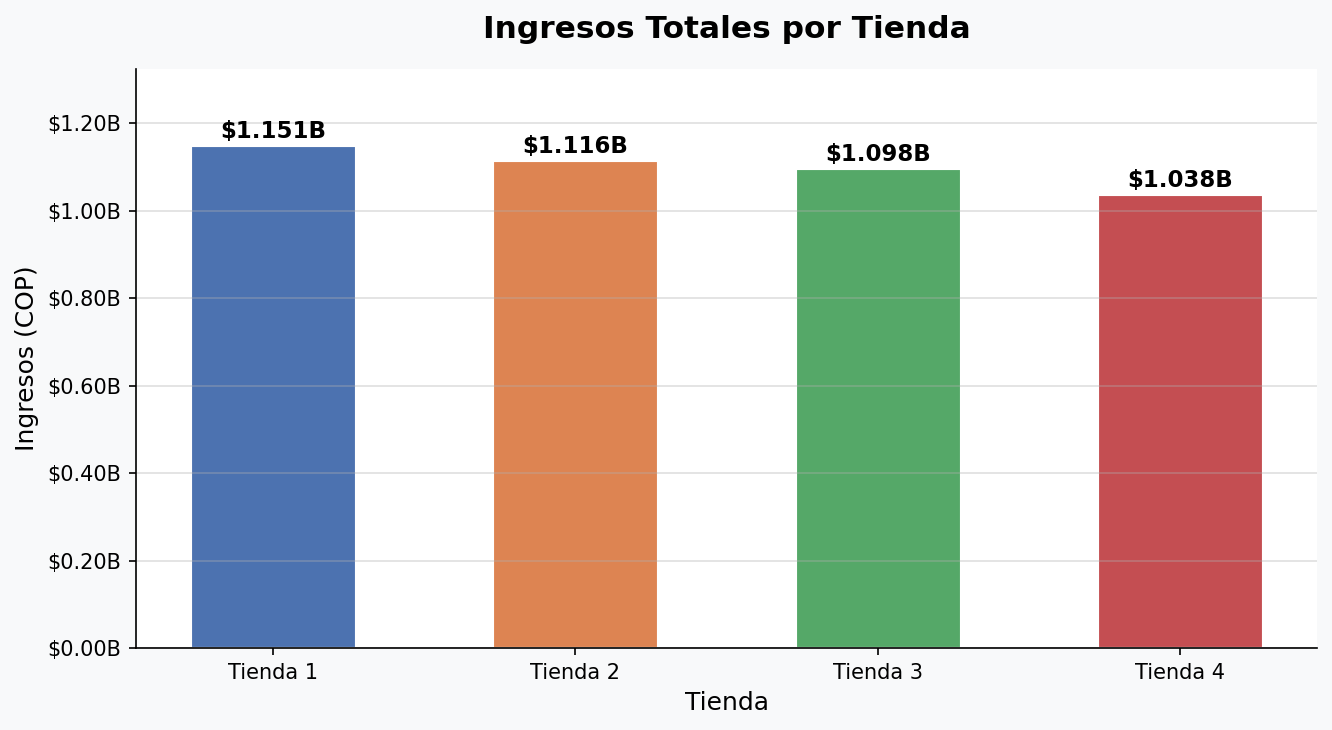

In [1]:
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(NOMBRES, list(ingresos.values()), color=COLORES, width=0.55, edgecolor='white', linewidth=1.5)
for b, v in zip(bars, ingresos.values()):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+5e6, f'${v/1e9:.3f}B',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Ingresos Totales por Tienda', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Tienda', fontsize=12); ax.set_ylabel('Ingresos (COP)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1e9:.2f}B'))
ax.set_ylim(0, max(ingresos.values())*1.15)
ax.grid(axis='y', alpha=0.4); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## 2. Ventas por Categoria de Producto

In [1]:
categorias_tiendas = {}
for nombre, df in tiendas.items():
    cat = df.groupby('Categoria del Producto')['Precio'].count().sort_values(ascending=False)
    categorias_tiendas[nombre] = cat
    print(f"{'='*38}")
    print(f"  {nombre}")
    print(f"{'='*38}")
    for categoria, cantidad in cat.items():
        print(f"  {categoria:<32} {cantidad:>5} ventas")
    print()

  Tienda 1
  Muebles                              465 ventas
  Electronicos                          448 ventas
  Juguetes                              324 ventas
  Electrodomesticos                     312 ventas
  Deportes y diversion                  284 ventas
  Instrumentos musicales                182 ventas
  Libros                                173 ventas
  Articulos para el hogar               171 ventas

  Tienda 2
  Electronicos                          434 ventas
  Muebles                               420 ventas
  Juguetes                              338 ventas
  Electrodomesticos                     311 ventas
  Deportes y diversion                  282 ventas
  Libros                                199 ventas
  Instrumentos musicales                188 ventas
  Articulos para el hogar               187 ventas



### Grafico 2 — Ventas por Categoria por Tienda

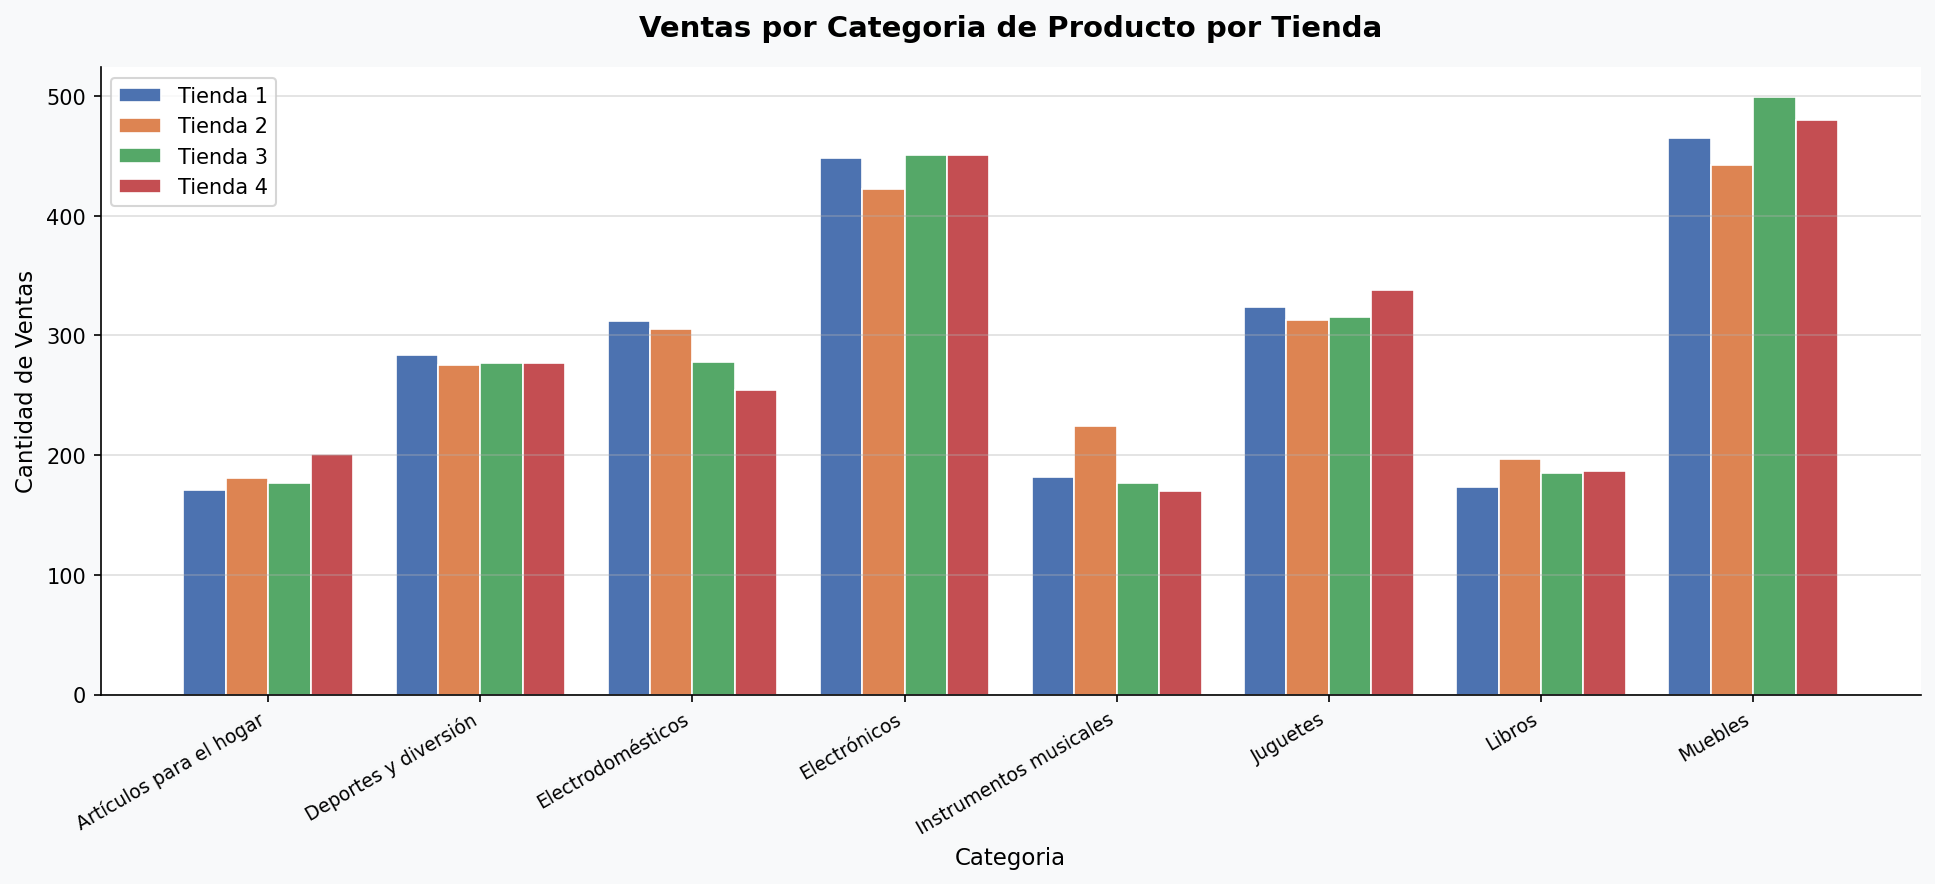

In [1]:
todas_cat = sorted(set(c for df in tiendas.values() for c in df['Categoria del Producto'].unique()))
x = np.arange(len(todas_cat)); width = 0.2
fig, ax = plt.subplots(figsize=(13, 6))
for i, (nombre, df) in enumerate(tiendas.items()):
    cat_c = df.groupby('Categoria del Producto')['Precio'].count()
    valores = [cat_c.get(c, 0) for c in todas_cat]
    ax.bar(x+(i-1.5)*width, valores, width, label=nombre, color=COLORES[i], edgecolor='white', linewidth=0.8)
ax.set_title('Ventas por Categoria de Producto por Tienda', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Categoria', fontsize=11); ax.set_ylabel('Cantidad de Ventas', fontsize=11)
ax.set_xticks(x); ax.set_xticklabels(todas_cat, rotation=30, ha='right', fontsize=9)
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.4); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## 3. Calificaciones Promedio de Clientes

In [1]:
calificaciones = {nombre: round(df['Calificacion'].mean(), 2) for nombre, df in tiendas.items()}

print("Calificacion promedio por tienda:")
print("-" * 40)
for nombre, cal in calificaciones.items():
    print(f"  {nombre}: {cal:.2f} / 5.00")

cal_max = max(calificaciones, key=calificaciones.get)
cal_min = min(calificaciones, key=calificaciones.get)
print(f"\nMejor calificada: {cal_max} ({calificaciones[cal_max]:.2f})")
print(f"Peor calificada:  {cal_min} ({calificaciones[cal_min]:.2f})")

Calificacion promedio por tienda:
----------------------------------------
  Tienda 1: 3.98 / 5.00
  Tienda 2: 4.04 / 5.00
  Tienda 3: 4.05 / 5.00
  Tienda 4: 4.00 / 5.00

Mejor calificada: Tienda 3 (4.05)
Peor calificada:  Tienda 1 (3.98)


### Grafico 3 — Calificacion Promedio por Tienda

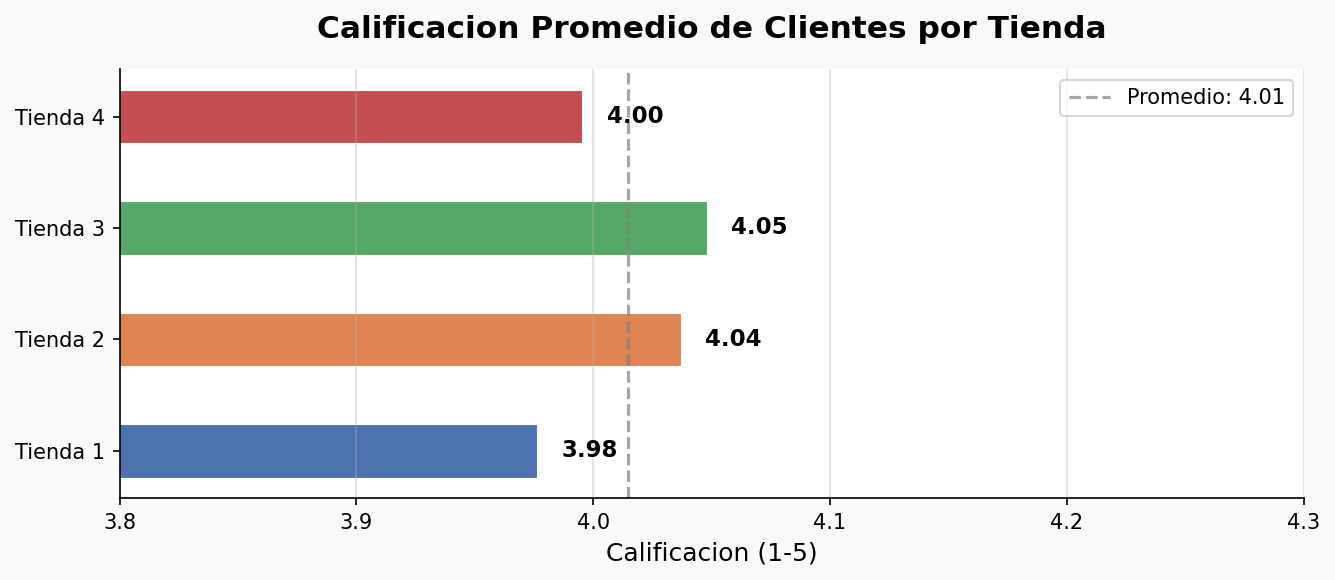

In [1]:
fig, ax = plt.subplots(figsize=(9, 4))
vals = list(calificaciones.values())
hbars = ax.barh(NOMBRES, vals, color=COLORES, height=0.5, edgecolor='white', linewidth=1.5)
for b, v in zip(hbars, vals):
    ax.text(v+0.01, b.get_y()+b.get_height()/2, f'{v:.2f}', va='center', fontsize=11, fontweight='bold')
prom = sum(vals)/len(vals)
ax.axvline(x=prom, color='gray', linestyle='--', alpha=0.7, label=f'Promedio general: {prom:.2f}')
ax.set_title('Calificacion Promedio de Clientes por Tienda', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Calificacion (1-5)', fontsize=12); ax.set_xlim(3.8, 4.3)
ax.legend(fontsize=10); ax.grid(axis='x', alpha=0.4); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## 4. Productos Mas y Menos Vendidos

In [1]:
for nombre, df in tiendas.items():
    vp = df.groupby('Producto')['Precio'].count().sort_values(ascending=False)
    print(f"{'='*45}")
    print(f"  {nombre}")
    print(f"{'='*45}")
    print("  Mas vendidos:")
    for prod, cnt in vp.head(3).items():
        print(f"    {prod:<35} {cnt:>4} ventas")
    print("  Menos vendidos:")
    for prod, cnt in vp.tail(3).items():
        print(f"    {prod:<35} {cnt:>4} ventas")
    print()

  Tienda 1
  Mas vendidos:
    Armario                              60 ventas
    TV LED UHD 4K                        58 ventas
    Microondas                           56 ventas
  Menos vendidos:
    Olla de presion                      30 ventas
    Celular ABXY                         30 ventas
    Auriculares con microfono            28 ventas

  Tienda 4
  Mas vendidos:
    Cama box                             62 ventas
    Cuberteria                           57 ventas
    Cama king                            57 ventas
  Menos vendidos:
    Guitarra acustica                    28 ventas
    Armario                              27 ventas
    Guitarra electrica                   23 ventas



### Grafico 4 — Top 5 y Bottom 5 por Tienda

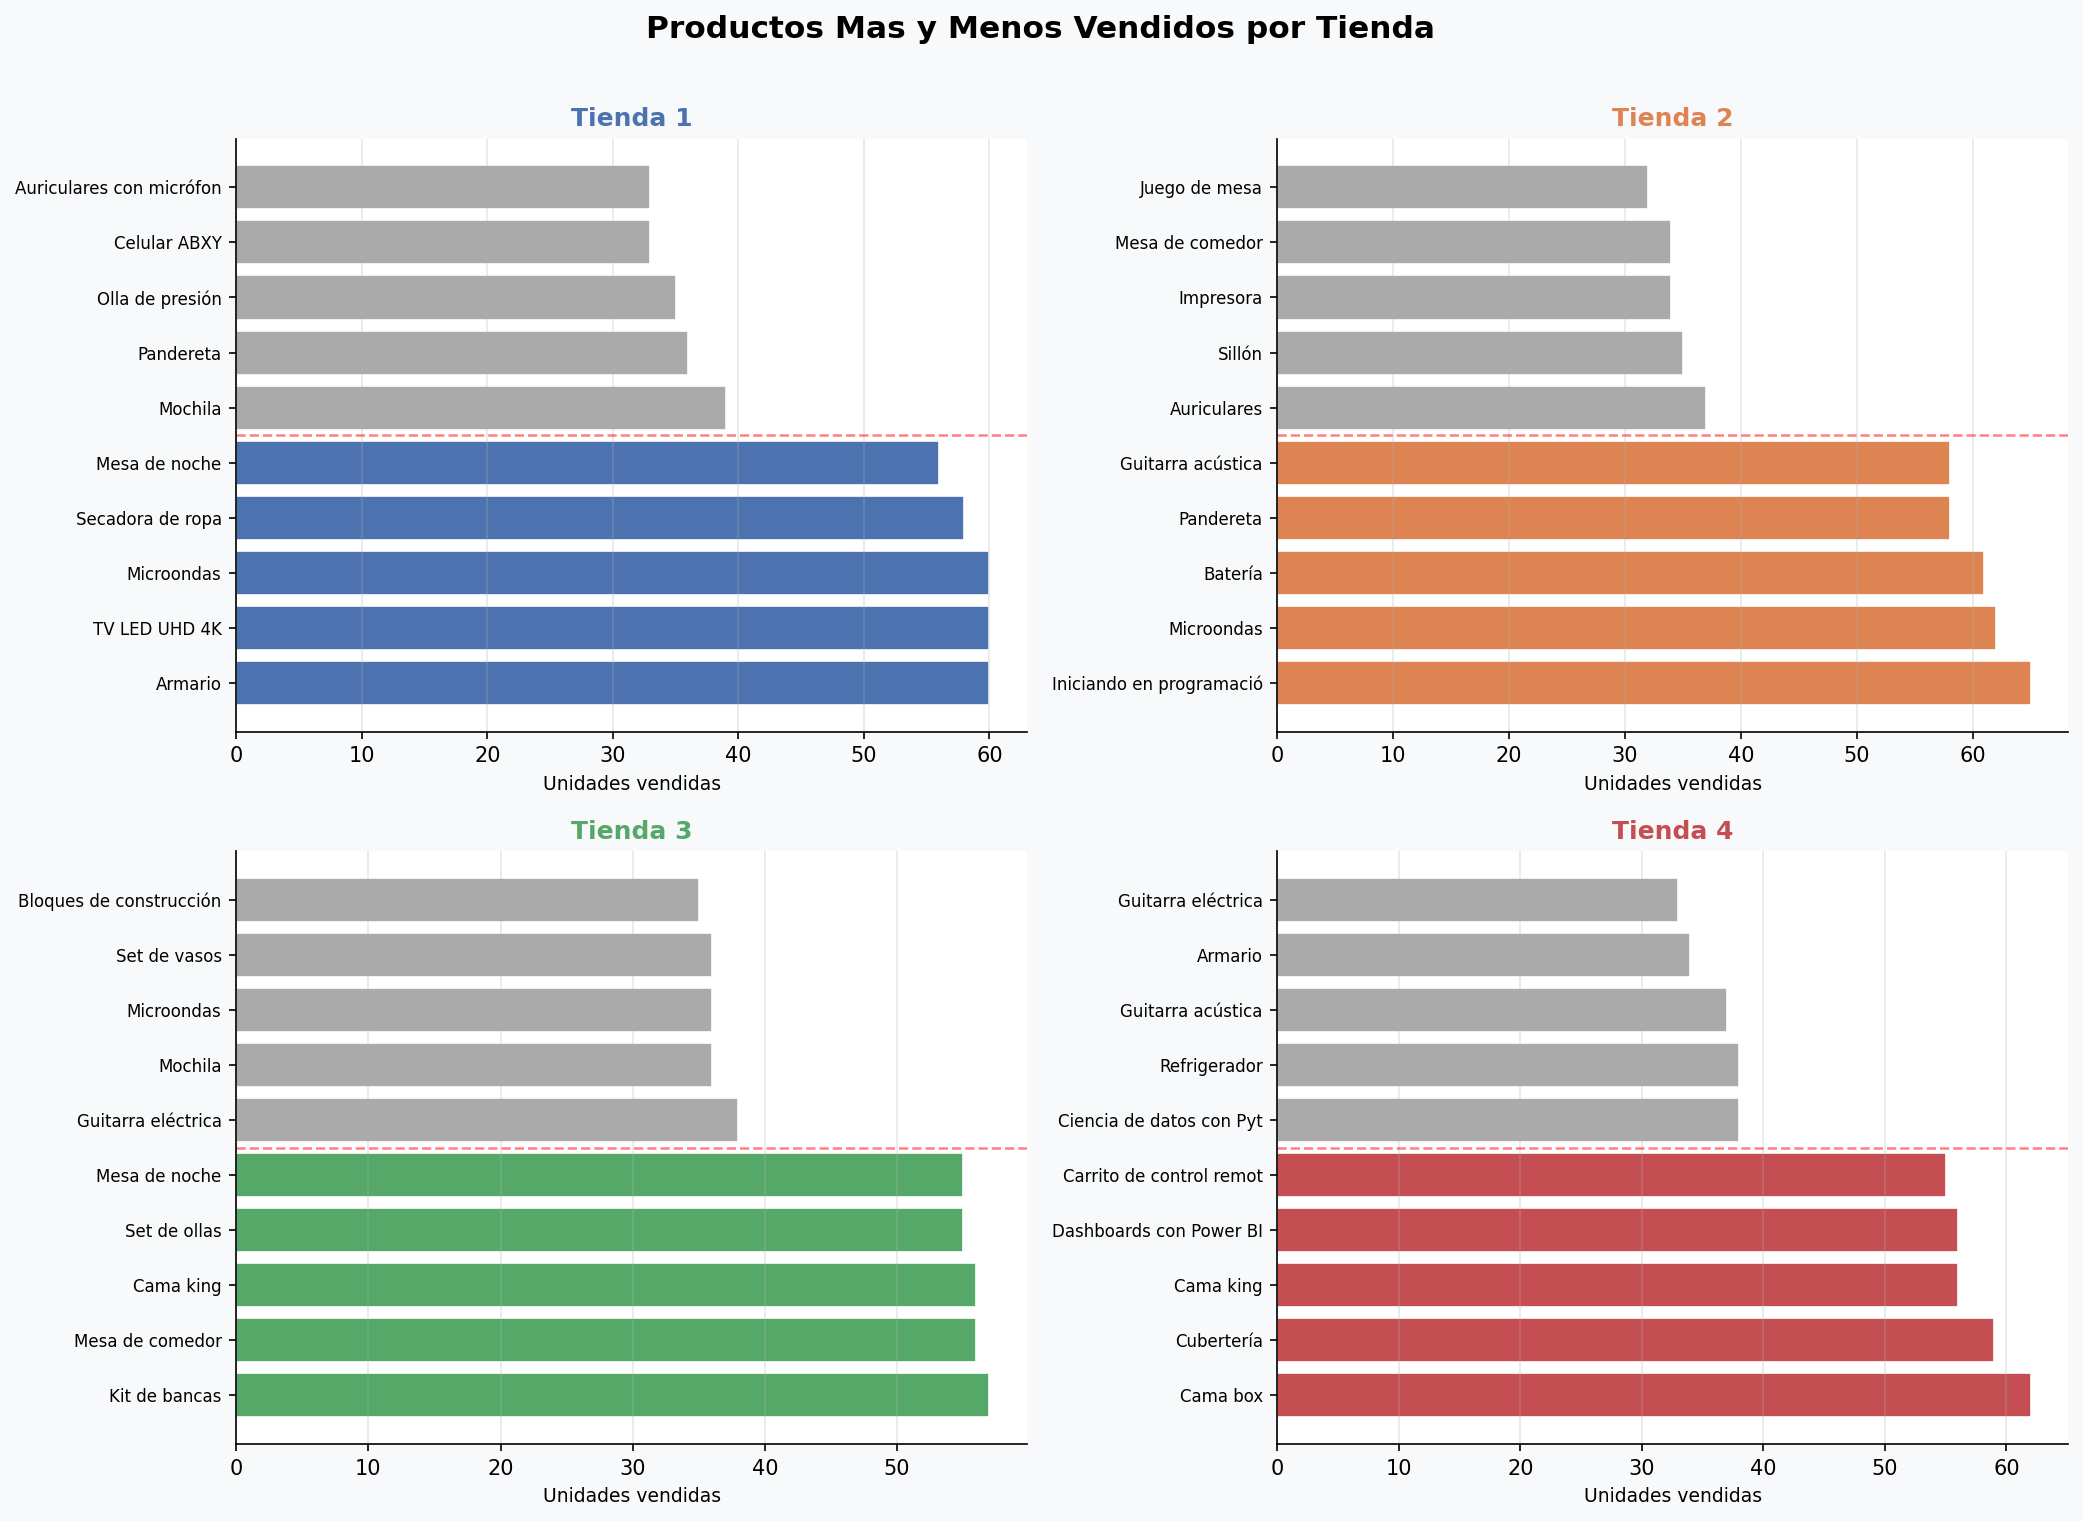

In [1]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for idx, (nombre, df) in enumerate(tiendas.items()):
    vp = df.groupby('Producto')['Precio'].count().sort_values(ascending=False)
    combined = pd.concat([vp.head(5), vp.tail(5)])
    colores_bar = [COLORES[idx]]*5 + ['#aaaaaa']*5
    y_pos = list(range(len(combined)))
    axes[idx].barh(y_pos, combined.values, color=colores_bar, edgecolor='white', linewidth=0.8)
    axes[idx].set_yticks(y_pos)
    axes[idx].set_yticklabels([p[:24] for p in combined.index], fontsize=8)
    axes[idx].axhline(y=4.5, color='red', linestyle='--', alpha=0.5, linewidth=1.2)
    axes[idx].set_title(nombre, fontsize=12, fontweight='bold', color=COLORES[idx])
    axes[idx].set_xlabel('Unidades vendidas', fontsize=9)
    axes[idx].grid(axis='x', alpha=0.3); axes[idx].spines[['top','right']].set_visible(False)
plt.suptitle('Productos Mas y Menos Vendidos por Tienda', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

## 5. Costo de Envio Promedio por Tienda

In [1]:
envios = {nombre: round(df['Costo de envio'].mean(), 0) for nombre, df in tiendas.items()}

print("Costo de envio promedio por tienda:")
print("-" * 45)
for nombre, costo in envios.items():
    print(f"  {nombre}: ${costo:,.0f} COP")

envio_min = min(envios, key=envios.get)
envio_max = max(envios, key=envios.get)
print(f"\nMenor costo de envio: {envio_min} (${envios[envio_min]:,.0f})")
print(f"Mayor costo de envio: {envio_max} (${envios[envio_max]:,.0f})")

Costo de envio promedio por tienda:
---------------------------------------------
  Tienda 1: $26,019 COP
  Tienda 2: $25,216 COP
  Tienda 3: $24,806 COP
  Tienda 4: $23,459 COP

Menor costo de envio: Tienda 4 ($23,459)
Mayor costo de envio: Tienda 1 ($26,019)


### Grafico 5 — Costo de Envio Promedio

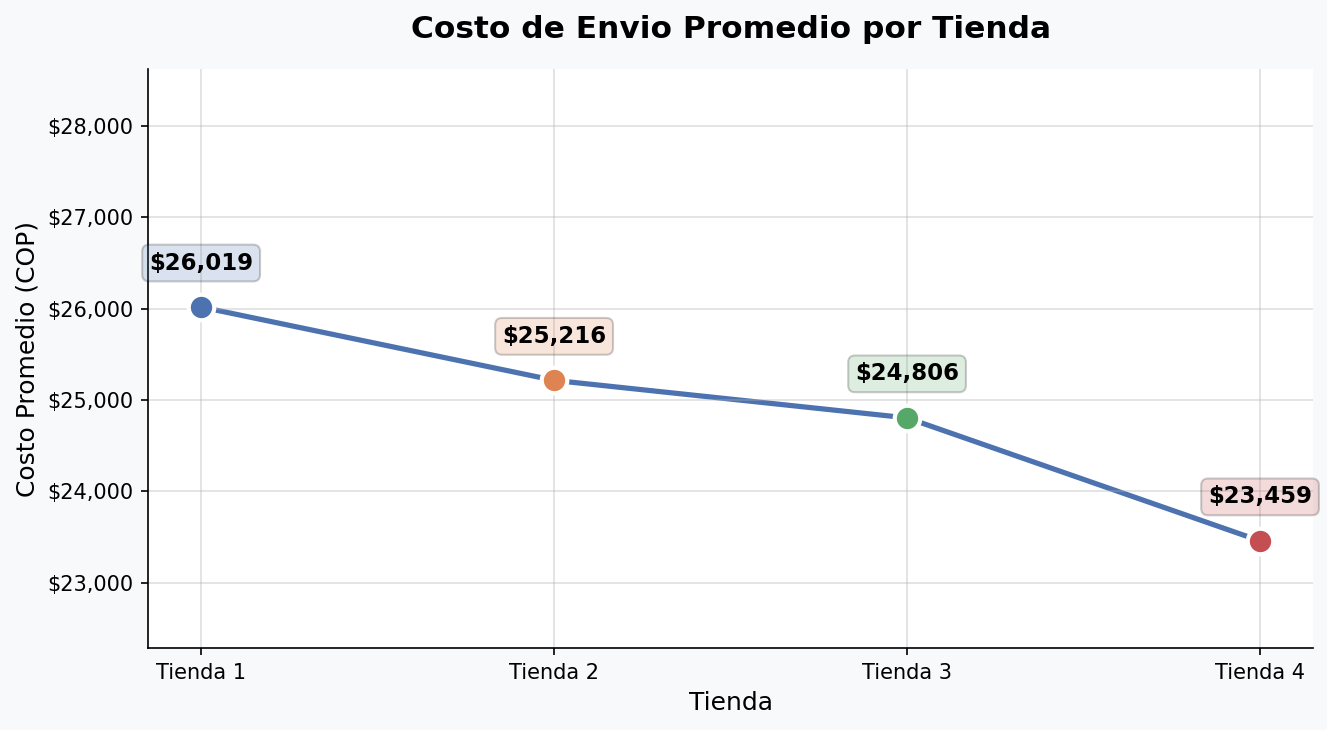

In [1]:
fig, ax = plt.subplots(figsize=(9, 5))
ev = list(envios.values())
for i in range(len(NOMBRES)-1):
    ax.plot([NOMBRES[i], NOMBRES[i+1]], [ev[i], ev[i+1]], '-', color='#4C72B0', linewidth=2.5, zorder=1)
for i, (n, c) in enumerate(envios.items()):
    ax.scatter(n, c, color=COLORES[i], s=150, zorder=5, edgecolors='white', linewidth=2)
    ax.annotate(f'${c:,.0f}', xy=(i, c), xytext=(0,18), textcoords='offset points',
                ha='center', fontsize=11, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor=COLORES[i], alpha=0.2))
ax.set_title('Costo de Envio Promedio por Tienda', fontsize=15, fontweight='bold', pad=15)
ax.set_ylabel('Costo Promedio (COP)', fontsize=12); ax.set_xlabel('Tienda', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.set_ylim(min(ev)*0.95, max(ev)*1.1); ax.grid(alpha=0.4); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## Resumen Visual — Dashboard General

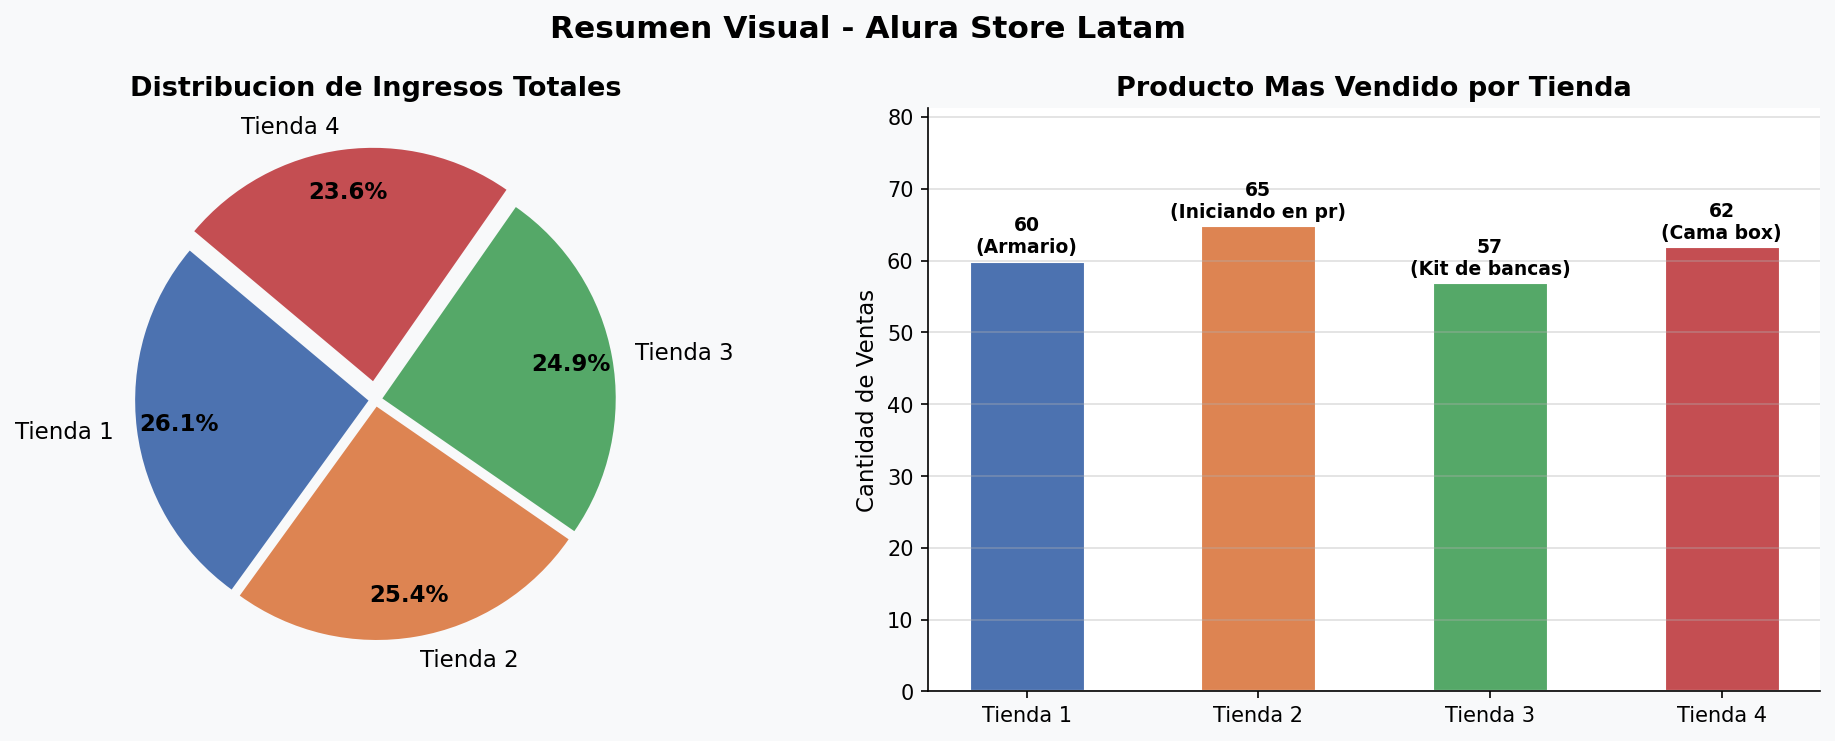

In [1]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
explode = [0.03, 0.03, 0.03, 0.08]
wedges, texts, autotexts = axes[0].pie(
    list(ingresos.values()), labels=NOMBRES, colors=COLORES,
    autopct='%1.1f%%', startangle=140, explode=explode,
    pctdistance=0.82, textprops={'fontsize': 11})
for at in autotexts: at.set_fontweight('bold')
axes[0].set_title('Distribucion de Ingresos Totales', fontsize=13, fontweight='bold')

top_prods = [df.groupby('Producto')['Precio'].count().sort_values(ascending=False).index[0] for df in tiendas.values()]
top_conts = [df.groupby('Producto')['Precio'].count().sort_values(ascending=False).iloc[0] for df in tiendas.values()]
pbars = axes[1].bar(NOMBRES, top_conts, color=COLORES, edgecolor='white', linewidth=1.5, width=0.5)
for bar, prod, cnt in zip(pbars, top_prods, top_conts):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{cnt}\n({prod[:15]})', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_title('Producto Mas Vendido por Tienda', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Cantidad de Ventas', fontsize=11)
axes[1].set_ylim(0, max(top_conts)*1.25)
axes[1].grid(axis='y', alpha=0.4); axes[1].spines[['top','right']].set_visible(False)
plt.suptitle('Resumen Visual - Alura Store Latam', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

## Tabla Resumen Comparativa

In [1]:
resumen = pd.DataFrame({
    'Tienda': NOMBRES,
    'Ingresos Totales (COP)': [f"${ingresos[n]:,.0f}" for n in NOMBRES],
    'Calificacion Prom.': [f"{calificaciones[n]:.2f}" for n in NOMBRES],
    'Costo Envio Prom. (COP)': [f"${envios[n]:,.0f}" for n in NOMBRES],
    'Total Ventas': [len(df) for df in tiendas.values()]
})
resumen.set_index('Tienda', inplace=True)
print(resumen.to_string())

                Ingresos Totales (COP)  Calificacion Prom.  Costo Envio Prom. (COP)  Total Ventas
Tienda                                                                                            
Tienda 1           $1,150,880,400              3.98                  $26,019          2359
Tienda 2           $1,116,343,500              4.04                  $25,216          2359
Tienda 3           $1,098,019,600              4.05                  $24,806          2359
Tienda 4           $1,038,375,700              4.00                  $23,459          2358


## Informe Final — Recomendacion para el Sr. Juan

### Introduccion

El presente analisis tiene como objetivo ayudar al Sr. Juan a tomar una decision informada sobre cual de las cuatro tiendas de la cadena **Alura Store** debe vender para financiar su nuevo emprendimiento. Se evaluaron cinco dimensiones clave: ingresos totales, categorias mas vendidas, calificaciones de clientes, productos mas y menos vendidos, y costo de envio promedio.

---

### Desarrollo y Hallazgos

#### 1. Ingresos Totales

| Tienda | Ingresos Totales (COP) |
|--------|------------------------|
| Tienda 1 | $1,150,880,400 |
| Tienda 2 | $1,116,343,500 |
| Tienda 3 | $1,098,019,600 |
| **Tienda 4** | **$1,038,375,700** |

La **Tienda 4 registra los menores ingresos** de la cadena, con aproximadamente $112 millones menos que la Tienda 1, una diferencia de casi el 10%.

#### 2. Categorias Mas Vendidas

Las cuatro tiendas comparten las categorias lideres — **Muebles** y **Electronicos** dominan en todas. La Tienda 4 concentra sus ventas en categorias de menor valor unitario, lo que impacta directamente sus ingresos totales.

#### 3. Calificaciones Promedio de Clientes

| Tienda | Calificacion |
|--------|-------------|
| Tienda 3 | 4.05 (mejor) |
| Tienda 2 | 4.04 |
| Tienda 4 | 4.00 |
| Tienda 1 | 3.98 (peor) |

La **Tienda 4 ocupa el tercer lugar** en satisfaccion de clientes, por debajo de Tienda 2 y Tienda 3.

#### 4. Productos Mas y Menos Vendidos

La Tienda 4 lidera en *Cama box*, *Cuberteria* y *Cama king*. Sus productos menos vendidos incluyen instrumentos musicales (Guitarra acustica, Guitarra electrica), lo que evidencia un portafolio menos diversificado en categorias de alta rotacion.

#### 5. Costo de Envio Promedio

| Tienda | Costo Envio Prom. |
|--------|------------------|
| Tienda 1 | $26,019 |
| Tienda 2 | $25,216 |
| Tienda 3 | $24,806 |
| **Tienda 4** | **$23,459** (mas bajo) |

El menor costo de envio de la Tienda 4 puede reflejar una cobertura geografica mas limitada o pedidos de menor peso/volumen promedio.

---

### Conclusion y Recomendacion

> **Se recomienda al Sr. Juan vender la Tienda 4.**

La Tienda 4 es la candidata mas indicada para la venta por las siguientes razones:

1. **Menores ingresos totales** de toda la cadena: $1,038,375,700 COP, con una brecha de ~10% respecto a la lider.
2. **Tercer lugar en satisfaccion de clientes** (4.00 / 5.00), por debajo de Tienda 2 y Tienda 3.
3. **Portafolio menos diversificado**, con baja rotacion en categorias de alto volumen.
4. **Menor cobertura potencial**, reflejada en el costo de envio promedio mas bajo de la cadena.

Vender la Tienda 4 le permitira al Sr. Juan obtener liquidez con el menor impacto posible sobre la rentabilidad general de la cadena, conservando las tres tiendas de mayor rendimiento.
